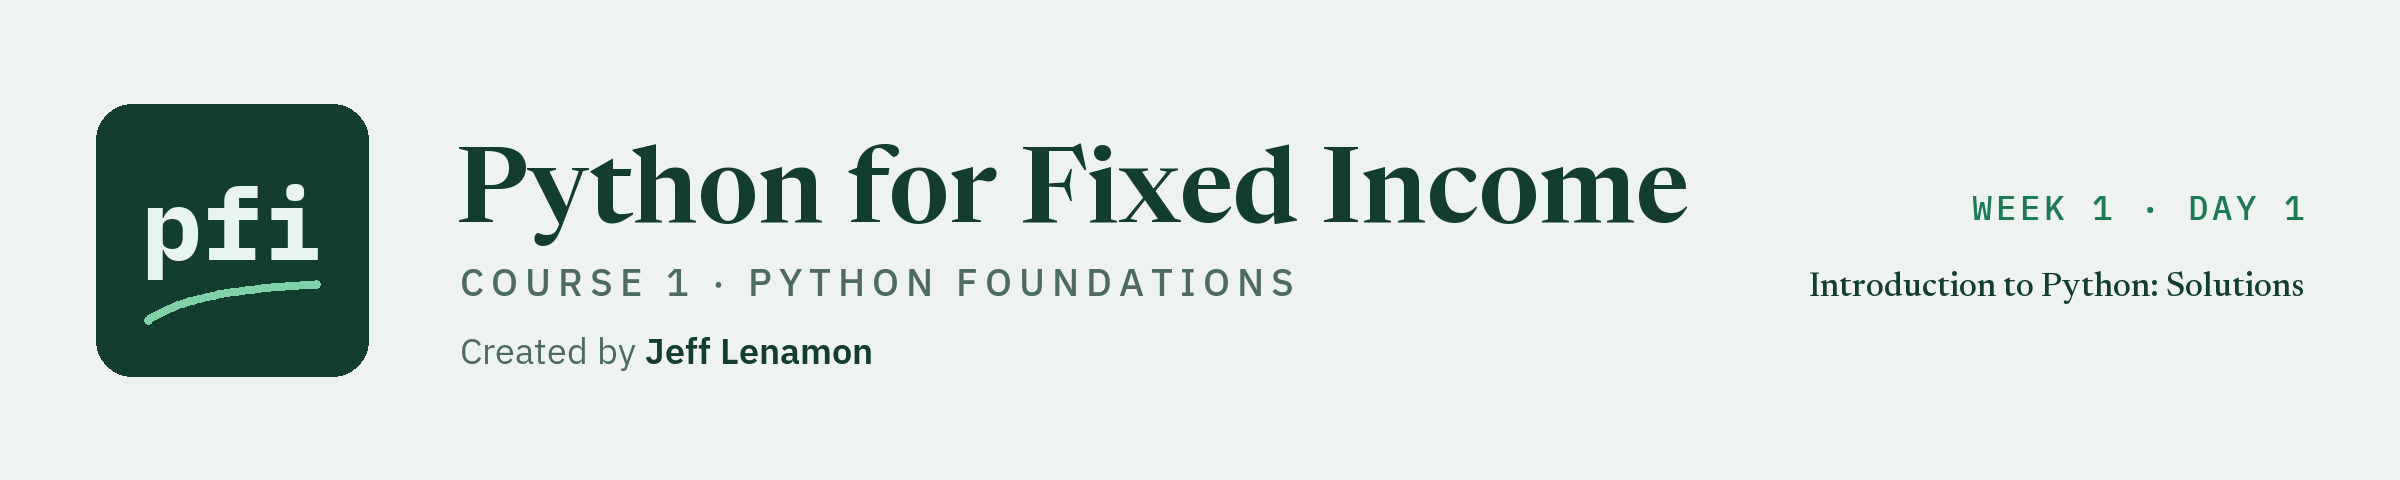

# Python for Fixed Income: Introduction - Solutions

Week 1. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week1/day1/01_python_for_fixed_income_intro_solutions.ipynb)

## Exercises

A second desk holds three different bonds. Use what you learned above to answer its questions. The issuers are invented.

| Ticker | Issuer | Coupon (%) | Maturity | Price | Rating | Face held |
| --- | --- | --- | --- | --- | --- | --- |
| TRNW | Tarnwick Utilities | 4.375 | 2030 | 96.25 | A | 2,000,000 |
| OSMC | Osmere Chemicals | 5.00 | 2035 | 100.00 | BBB- | 1,250,000 |
| CLDB | Calderby Retail | 8.25 | 2031 | 104.50 | B | 500,000 |

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It defines `check`, a small function that marks your answers.

In [1]:
def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
    elif answer == expected:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)

### Exercise 1

Q. Store the coupon, price, and face held of TRNW in variables. What is the annual coupon income of the position, and what did the position cost at the clean price? Store the answers in **ex1_income** and **ex1_cost**.

In [2]:
# store the coupon (in percent), price, and face held of TRNW
coupon = 4.375
price = 96.25
face = 2000000
# the coupon is in percent, so divide by 100
ex1_income = face * coupon / 100
# the price is per 100 face, so divide by 100
ex1_cost = face * price / 100
print(f'The annual coupon income is ${ex1_income:,.2f}')
print(f'The position cost ${ex1_cost:,.2f}')

The annual coupon income is $87,500.00
The position cost $1,925,000.00


In [3]:
check('Exercise 1 income', ex1_income, 87500.0)
check('Exercise 1 cost', ex1_cost, 1925000.0)

Exercise 1 income: correct
Exercise 1 cost: correct


### Exercise 2

Q. Create a list for the tickers, coupons, prices, and face held of the three bonds. Then find the highest coupon, the total face held, and the simple average price. Store the answers in **ex2_highest_coupon**, **ex2_total_face**, and **ex2_average_price**.

In [4]:
# create the lists, keeping the bonds in the same order in each
ticker_list = ['TRNW', 'OSMC', 'CLDB']
coupon_list = [4.375, 5.0, 8.25]
price_list = [96.25, 100.0, 104.5]
face_list = [2000000, 1250000, 500000]
# highest coupon
ex2_highest_coupon = max(coupon_list)
# total face held
ex2_total_face = sum(face_list)
# simple average price
ex2_average_price = sum(price_list) / len(price_list)
print(f'The highest coupon is {ex2_highest_coupon:.3f} percent')
print(f'The total face held is {ex2_total_face:,}')
print(f'The average price is {ex2_average_price:.2f}')

The highest coupon is 8.250 percent
The total face held is 3,750,000
The average price is 100.25


In [5]:
check('Exercise 2 highest coupon', ex2_highest_coupon, 8.25)
check('Exercise 2 total face', ex2_total_face, 3750000)
check('Exercise 2 average price', ex2_average_price, 100.25)

Exercise 2 highest coupon: correct
Exercise 2 total face: correct
Exercise 2 average price: correct


### Exercise 3

Q. Create a list that labels each of the three bonds as 'Premium', 'Discount', or 'Par' based on its price. Store it in **ex3_labels**. Use a loop with if, elif, and else.

In [6]:
# start with an empty list
ex3_labels = []
for price in price_list:
    if price > 100:
        ex3_labels.append('Premium')
    elif price < 100:
        ex3_labels.append('Discount')
    else:
        ex3_labels.append('Par')

print(ex3_labels)

['Discount', 'Par', 'Premium']


* OSMC is priced at exactly 100, so it falls through both tests and lands in the `else`.

In [7]:
check('Exercise 3', ex3_labels, ['Discount', 'Par', 'Premium'])

Exercise 3: correct


### Exercise 4

Q. Write a function **position_cost** that takes a face amount and a price and returns the cost of the position. Then use it in a loop to find the total cost of the three positions, and store it in **ex4_total_cost**.

In [8]:
# define the function
def position_cost(face, price):
    """
    Take the face held and the price (per 100 face)
    and return the cost of the position.
    """
    return face * price / 100


# start a running total at zero
ex4_total_cost = 0
for face, price in zip(face_list, price_list):
    # add the cost of this position to the running total
    ex4_total_cost = ex4_total_cost + position_cost(face, price)

print(f'The three positions cost ${ex4_total_cost:,.2f}')

The three positions cost $3,697,500.00


In [9]:
check('Exercise 4 function', position_cost(2000000, 96.25), 1925000.0)
check('Exercise 4 total cost', ex4_total_cost, 3697500.0)

Exercise 4 function: correct
Exercise 4 total cost: correct


### Exercise 5

Q. Store the three bonds as a list of dictionaries named **ex5_holdings**: one dictionary per bond, in the order of the table, each with the keys 'Ticker', 'Price', and 'Face'. Then use `get()` to look up the key 'Rating' in the first dictionary, with the fallback 'not recorded', and store the result in **ex5_rating**.

In [10]:
# one dictionary per bond, in the order of the table
ex5_holdings = [
    {'Ticker': 'TRNW', 'Price': 96.25, 'Face': 2000000},
    {'Ticker': 'OSMC', 'Price': 100.0, 'Face': 1250000},
    {'Ticker': 'CLDB', 'Price': 104.5, 'Face': 500000}
    ]
# index 0 is the first bond. It has no 'Rating' key, so get() returns the fallback
ex5_rating = ex5_holdings[0].get('Rating', 'not recorded')
print(f'The list holds {len(ex5_holdings)} bonds')
print(f'The rating of the first bond is {ex5_rating}')

The list holds 3 bonds
The rating of the first bond is not recorded


* The dictionaries hold no 'Rating' key, so `get()` handed back the fallback. With square brackets, `ex5_holdings[0]['Rating']` would have stopped with an error.

In [11]:
check('Exercise 5 holdings', ex5_holdings, [
    {'Ticker': 'TRNW', 'Price': 96.25, 'Face': 2000000},
    {'Ticker': 'OSMC', 'Price': 100.0, 'Face': 1250000},
    {'Ticker': 'CLDB', 'Price': 104.5, 'Face': 500000}
    ])
check('Exercise 5 rating', ex5_rating, 'not recorded')

Exercise 5 holdings: correct
Exercise 5 rating: correct


### Exercise 6

Q. The desk describes CLDB with the text 'CLDB 8.25 2031'. Use slicing to store the ticker in **ex6_ticker** and the maturity year, as a whole number, in **ex6_maturity**. The rating arrives as the text ' b ', in lower case with a space on each side. Clean it into 'B' and store it in **ex6_rating**.

In [12]:
description = 'CLDB 8.25 2031'
rating_text = ' b '

# the ticker is the first 4 characters
ex6_ticker = description[:4]
# the year is the last 4 characters. int() turns the text into a whole number
ex6_maturity = int(description[-4:])
# strip() removes the spaces and upper() makes the letter a capital
ex6_rating = rating_text.strip().upper()
print(f'{ex6_ticker} matures in {ex6_maturity} and is rated {ex6_rating}')

CLDB matures in 2031 and is rated B


* A negative start counts from the end, so `description[-4:]` is the last four characters whatever the length of the string.

In [13]:
check('Exercise 6 ticker', ex6_ticker, 'CLDB')
check('Exercise 6 maturity', ex6_maturity, 2031)
check('Exercise 6 rating', ex6_rating, 'B')

Exercise 6 ticker: correct
Exercise 6 maturity: correct
Exercise 6 rating: correct


### Exercise 7

Q. The three positions cost 3,697,500 dollars in total, the answer to Exercise 4. Use an f-string and the variable below to build the sentence 'The three positions cost $3,697,500.00', and store it in **ex7_sentence**.

In [14]:
total_cost = 3697500.0

# the comma adds thousands separators and .2f shows 2 decimals
ex7_sentence = f'The three positions cost ${total_cost:,.2f}'
print(ex7_sentence)

The three positions cost $3,697,500.00


In [15]:
check('Exercise 7', ex7_sentence, 'The three positions cost $3,697,500.00')

Exercise 7: correct


### Exercise 8

Q. Complete the function **coupon_income**. It takes a face amount, a coupon in percent, and a number of months that defaults to 12, and it returns the coupon income for that period in dollars.

In [16]:
def coupon_income(face, coupon, months=12):
    """
    Take the face held, the coupon (in percent), and the number of months,
    and return the coupon income for that period in dollars.
    """
    # the coupon is in percent, so divide by 100 for a year of income
    annual_income = face * coupon / 100
    # scale the year to the period asked for
    return annual_income * months / 12


print(f'TRNW pays ${coupon_income(2000000, 4.375):,.2f} in a year')
print(f'TRNW pays ${coupon_income(2000000, 4.375, months=6):,.2f} in six months')

TRNW pays $87,500.00 in a year
TRNW pays $43,750.00 in six months


* The function returns a number and prints nothing itself, so the result can be formatted, stored, or used in another calculation.

In [17]:
check('Exercise 8 full year', coupon_income(2000000, 4.375), 87500.0)
check('Exercise 8 six months', coupon_income(2000000, 4.375, months=6), 43750.0)

Exercise 8 full year: correct
Exercise 8 six months: correct


### Exercise 9: AI check

You ask an AI assistant for code that totals the face held across the three positions. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug. This is the routine from section 1.9: read, predict, run, check.

Q. Read the code before you run it. What will it print? Then run it.

In [18]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
face_list = [2000000, 1250000, 500000]

for face in face_list:
    total_face = 0
    total_face = total_face + face

print(f'The total face held is {total_face:,}')

The total face held is 500,000


Q. Is that answer believable? You worked out the total face yourself in Exercise 2. Use that as your reference, find the bug, and store the corrected total in **ex9_total_face**.

* The code runs with no error and prints 500,000, which is only the last position. Your own answer from Exercise 2 was 3,750,000, so something is wrong.
* The bug is the line `total_face = 0` inside the loop. It resets the running total on every pass, so only the last face amount survives. The total has to start at zero once, before the loop.

In [19]:
# start the running total once, before the loop
ex9_total_face = 0
for face in face_list:
    ex9_total_face = ex9_total_face + face

print(f'The total face held is {ex9_total_face:,}')

The total face held is 3,750,000


* Code can run cleanly and still be wrong. The habit is the same every time: read it, predict the answer, run it, and check it against a number you trust.

In [20]:
check('Exercise 9', ex9_total_face, 3750000)

Exercise 9: correct
